# Assignment Instruction 
### Project Tilte :Customer Churn Predication Using Deeplearning and Machine Learning Models

You are provided with a bank customers dataset (Churn_Modelling.csv) with about 10,000 customer information that can be used to decide whether the customer is likely to churn. There are multiple features. Identify which features are significant in determining whether the customer will churn. The last column, “Exited,” tells whether the customer stayed with the bank (Exited = 0) or left the bank (Exited = 1). Write a python code to design a three-layered ANN classifier that can predict whether the customer will churn for the test data set, which is 20% of the total dataset. Print the confusion matrix and accuracy, and then, submit the python code.

Be sure to encode the categorical data and perform the feature scaling. Use ‘relu’ activation for the first and second layers and ‘sigmoid’ for the last dense layer. For compiling, use ‘adam’ optimizer; and loss should be ‘binary_crossentropy’ as this is a binary classification problem.

### 1- import Libraries and Load Data

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

### 1- load and explor the dataset

In [2]:
dataset = pd.read_csv("Churn_Modelling.csv")

In [3]:
print(dataset.head())

   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4         790

In [4]:
dataset.head(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### 2: Select Features and Target

In [17]:
# Select features and target
X = dataset.iloc[:, 3:13]
y = dataset.iloc[:, 13]

# One-hot encode categorical variables
geography = pd.get_dummies(X['Geography'], drop_first=False)
gender = pd.get_dummies(X['Gender'], drop_first=True)

# Combine encoded columns
X = pd.concat([X, geography, gender], axis=1)

# Drop original categorical columns
X.drop(['Geography', 'Gender'], axis=1, inplace=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)

X.head(20)


Shape of X_train: (8000, 12)
Shape of X_test: (2000, 12)


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,France,Germany,Spain,Male
0,619,42,2,0.00,1,1,1,101348.88,True,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,True,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,True,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,False,True,False
5,645,44,8,113755.78,2,1,0,149756.71,False,False,True,True
6,822,50,7,0.00,2,1,1,10062.80,True,False,False,True
7,376,29,4,115046.74,4,1,0,119346.88,False,True,False,False
8,501,44,4,142051.07,2,0,1,74940.50,True,False,False,True
9,684,27,2,134603.88,1,1,1,71725.73,True,False,False,True


In [6]:
dataset.info()
dataset.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


### 3: Build and Train Deep Learning Model (ANN)

In [7]:
# Initialize ANN
classifier = Sequential()

# Input layer + first hidden layer
classifier.add(Dense(units=6, activation='relu', input_dim=X_train.shape[1]))

# Second hidden layer
classifier.add(Dense(units=6, activation='relu'))

# Output layer
classifier.add(Dense(units=1, activation='sigmoid'))  # Binary classification

# Compile model
classifier.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train model
model_history = classifier.fit(X_train, y_train, validation_split=0.33,
                               batch_size=10, epochs=100, verbose=2)

c:\Users\ghaya\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
536/536 - 3s - 6ms/step - accuracy: 0.7317 - loss: 0.5624 - val_accuracy: 0.7910 - val_loss: 0.4785
Epoch 2/100
536/536 - 1s - 3ms/step - accuracy: 0.7981 - loss: 0.4567 - val_accuracy: 0.8050 - val_loss: 0.4467
Epoch 3/100
536/536 - 2s - 3ms/step - accuracy: 0.8115 - loss: 0.4314 - val_accuracy: 0.8092 - val_loss: 0.4304
Epoch 4/100
536/536 - 1s - 3ms/step - accuracy: 0.8130 - loss: 0.4145 - val_accuracy: 0.8103 - val_loss: 0.4202
Epoch 5/100
536/536 - 1s - 3ms/step - accuracy: 0.8238 - loss: 0.3980 - val_accuracy: 0.8258 - val_loss: 0.4064
Epoch 6/100
536/536 - 2s - 3ms/step - accuracy: 0.8427 - loss: 0.3814 - val_accuracy: 0.8300 - val_loss: 0.3950
Epoch 7/100
536/536 - 2s - 3ms/step - accuracy: 0.8474 - loss: 0.3695 - val_accuracy: 0.8334 - val_loss: 0.3885
Epoch 8/100
536/536 - 2s - 3ms/step - accuracy: 0.8498 - loss: 0.3621 - val_accuracy: 0.8383 - val_loss: 0.3828
Epoch 9/100
536/536 - 1s - 3ms/step - accuracy: 0.8535 - loss: 0.3563 - val_accuracy: 0.8413 - val_loss:

### 3: Evaluate ANN model

In [8]:
# Evaluate on test data
loss, accuracy = classifier.evaluate(X_test, y_test)
print("ANN Test Accuracy: {:.4f}".format(accuracy))

# Predictions
y_pred_ann = (classifier.predict(X_test) > 0.5).astype(int)

# Confusion matrix
cm_ann = confusion_matrix(y_test, y_pred_ann)
print("Confusion Matrix (ANN):\n", cm_ann)

# Classification report
print("Classification Report (ANN):\n", classification_report(y_test, y_pred_ann))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8600 - loss: 0.3390
ANN Test Accuracy: 0.8600
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  
Confusion Matrix (ANN):
 [[1513   94]
 [ 186  207]]
Classification Report (ANN):
               precision    recall  f1-score   support

           0       0.89      0.94      0.92      1607
           1       0.69      0.53      0.60       393

    accuracy                           0.86      2000
   macro avg       0.79      0.73      0.76      2000
weighted avg       0.85      0.86      0.85      2000



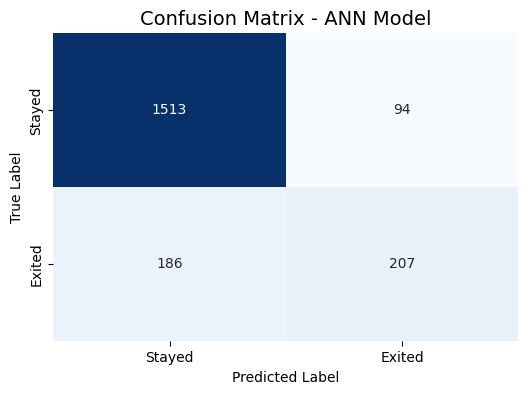

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Stayed', 'Exited'],
            yticklabels=['Stayed', 'Exited'])
plt.title('Confusion Matrix - ANN Model', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Plot Training History

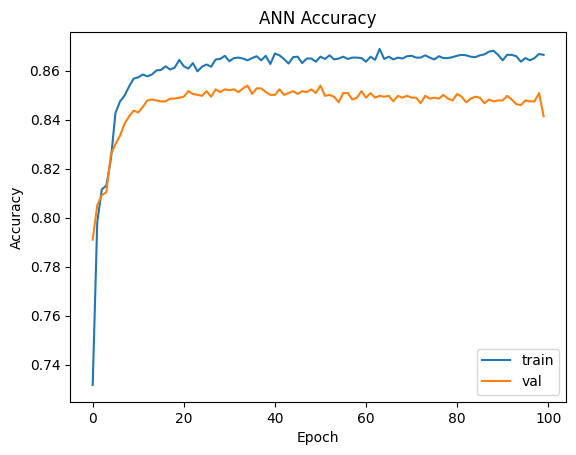

In [10]:
plt.plot(model_history.history['accuracy'], label='train')
plt.plot(model_history.history['val_accuracy'], label='val')
plt.title('ANN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### the Confusion metric show us
- True Negatives (TN) = 1541 → correctly predicted as Stayed

- False Positives (FP) = 66 → predicted as Exited but actually Stayed

- False Negatives (FN) = 213 → predicted as Stayed but actually Exited

- True Positives (TP) = 180 → correctly predicted as Exited

**Observation**: The model is better at predicting customers who stay than those who churn.

### Classification Report


| Metric        | Class 0 (Stayed) | Class 1 (Exited) |
| ------------- | ---------------- | ---------------- |
| **Precision** | 0.88             | 0.73             |
| **Recall**    | 0.96             | 0.46             |
| **F1-score**  | 0.92             | 0.56             |
| **Support**   | 1607             | 393              |


### Definitions:

**Precision**: Of all customers predicted as a class, how many were correct?

Class 1 Precision = 0.73 → 73% of predicted churns were correct.

**Recall (Sensitivity):** Of all actual customers in a class, how many did the model identify?

Class 1 Recall = 0.46 → Only 46% of actual churns were correctly detected.

**F1-score**: Harmonic mean of precision and recall; balances the two.

**Support:** Number of actual instances in each class.

### Observation:

- The model struggles to detect churned customers (class 1), shown by low recall (0.46) and moderate F1-score (0.56).

- It performs very well on predicting customers who stayed (class 0), recall 0.96, F1-score 0.92.

### Overall Metrics

- Accuracy: 0.86 → good overall, but imbalanced data means accuracy overestimates performance on minority class.

- Macro Avg: 0.74 → averages metrics across classes (treats both classes equally).

- Weighted Avg: 0.85 → accounts for class imbalance; dominated by the majority class (Stayed).

 ### Key Takeaways

The ANN predicts majority class (Stayed) very well, but minority class (Exited) less effectively.

For business use, recall for class 1 (churn) is critical — missing churned customers can hurt retention strategies.

To improve: consider class weighting, oversampling (SMOTE), or trying other ML models like Random Forest to better capture churn cases.

Note: The technical terminology of the dataset, alongside the data dictionary, as well as some coding syntax in the project, was clarified with assistance from OpenAI.

### save the entire ANN Model 

In [11]:
# Save the entire model to a file
classifier.save('ann_model.h5')  # HDF5 format


In [12]:
classifier.save('ann_model.keras')  # Native Keras format


In [13]:
from tensorflow.keras.models import load_model

loaded_classifier = load_model('ann_model.keras')


c:\Users\ghaya\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 8 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [14]:
# Now you can use it to predict
predictions = loaded_classifier.predict(X_test)
predictions = (predictions > 0.5).astype(int)  # For binary classification

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [15]:
import pickle
from sklearn.preprocessing import StandardScaler

# Save the scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(sc, f)


In [16]:
import pickle
from tensorflow.keras.models import load_model

# Load model
loaded_model = load_model('ann_model.keras')

# Load scaler
with open('scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)

# Transform new data
X_new_scaled = loaded_scaler.transform(X_new)

# Make predictions
predictions = loaded_model.predict(X_new_scaled)
predictions = (predictions > 0.5).astype(int)


NameError: name 'X_new' is not defined